# 03 - Visualize bill supportiveness over time

Reads the relevant and scored CSV produced by notebook 2 and creates a scatterplot of bill supportiveness over time.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
## load the scored bills produced by notebook 02
INPUT_CSV = "candidate_bills_data_center_relevant_scored.csv"

bills = pd.read_csv(INPUT_CSV)

print("Number of rows in the input data:", len(bills))
bills.head()


Number of rows in the input data: 255


,bill_id,state,session,identifier,title,abstract,abstract_word_count,first_action_date,latest_action_date,latest_passage_date,...,dc_relevance_error,supportiveness_score,supportiveness_confidence,supportiveness_reason,supportiveness_evidence_quote,supportiveness_evidence_verified,supportiveness_model,supportiveness_prompt_version,supportiveness_status,supportiveness_error
0,ocd-bill/d2396bbc-eb4a-498d-8b40-4e32093d3595,California,20232024,SB 284,Electricity: energization transparency and eff...,Existing law vests the Public Utilities Commis...,239,2023-02-01,2024-07-01,2023-04-10,...,NaN,6.0,0.80,Mandates utility data sharing for interconnect...,require each electrical corporation to provide...,False,qwen.qwen3.5-122b,data-center-supportiveness-v1,scored,NaN
1,ocd-bill/421d092b-7dbd-4f84-9fe4-90ba58b5b95b,California,20232024,SB 1018,Electricity.,The Public Utilities Act vests the Public Util...,573,2024-02-05,2024-08-15,2024-05-21,...,NaN,8.0,0.90,Establishes specific tariff and regulatory fra...,"require the commission... to evaluate and, if ...",False,qwen.qwen3.5-122b,data-center-supportiveness-v1,scored,NaN
2,ocd-bill/2d6d52a5-9a26-47d9-b583-2e61f397c5cd,California,20232024,SB 1298,Certification of thermal powerplants: data cen...,Existing law vests the State Energy Resources ...,282,2024-02-15,2024-08-27,2024-05-22,...,NaN,7.0,0.90,Exempts data center backup generators up to 15...,authorize the commission to exempt from certif...,True,qwen.qwen3.5-122b,data-center-supportiveness-v1,scored,NaN
3,ocd-bill/3b3c7eff-89ae-45c9-a5a1-adcec799b331,California,20252026,AB 93,Water resources: data centers.,Existing law authorizes the legislative body o...,326,2025-01-07,2026-01-22,2025-09-10,...,NaN,4.0,0.80,Adds reporting burdens and perjury risk for wa...,"provide its water supplier, under penalty of p...",True,qwen.qwen3.5-122b,data-center-supportiveness-v1,scored,NaN
4,ocd-bill/fd340120-32d7-4698-b737-9761b4b4c274,California,20252026,AB 222,Data centers: power usage effectiveness: cost ...,Existing law requires the State Energy Resourc...,305,2025-01-08,2025-08-29,2025-06-02,...,NaN,4.0,0.75,Mandates biannual PUE reporting and assesses c...,"submit the power usage effectiveness ratio, as...",True,qwen.qwen3.5-122b,data-center-supportiveness-v1,scored,NaN


In [7]:
## keep bills that notebook 2 marked relevant and then scored
relevant_mask = bills["dc_relevant"].str.lower() == "yes"
scored_mask = bills["supportiveness_status"].str.lower() == "scored"

plot_data = bills[relevant_mask & scored_mask].copy()

## convert the date and score columns to the types needed for plotting
plot_data["plot_date"] = pd.to_datetime(
    plot_data["first_action_date"],
    errors="coerce",
    format="mixed",
    utc=True
)

plot_data["score_numeric"] = pd.to_numeric(
    plot_data["supportiveness_score"],
    errors="coerce"
)

## remove rows that cannot be plotted
plot_data = plot_data.dropna(subset=["plot_date", "score_numeric"])

## add small reproducible jitter so overlapping bills remain visible (got help from ChatGPT here)
np.random.seed(42)
plot_data["jittered_score"] = (
    plot_data["score_numeric"]
    + np.random.uniform(-0.13, 0.13, len(plot_data))
)

print("Number of bills included in the plot:", len(plot_data))
plot_data["state"].value_counts()


Number of bills included in the plot: 236


state
Virginia      116
Illinois       50
Georgia        22
Texas          21
California     15
Ohio           12
Name: count, dtype: int64

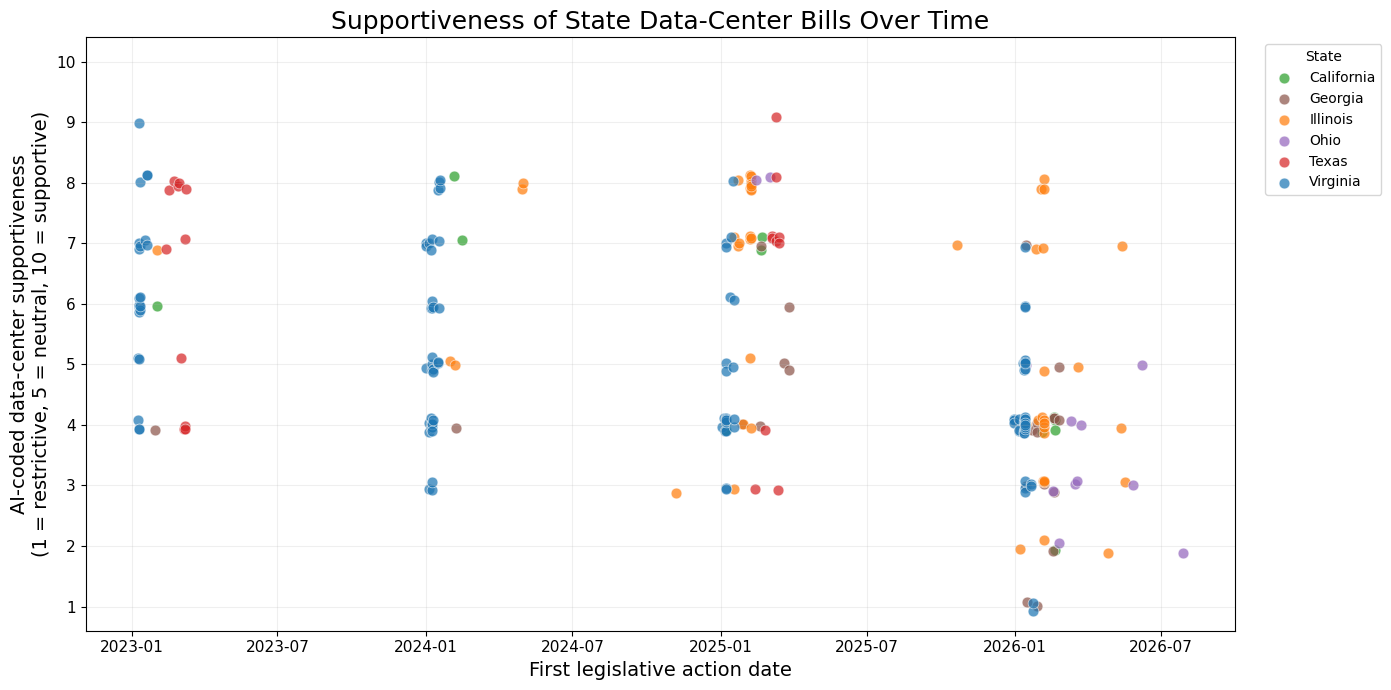

In [10]:
## assign a consistent color to each state
state_colors = {
    "California": "#2ca02c",
    "Illinois": "#ff7f0e",
    "Virginia": "#1f77b4",
    "Texas": "#d62728",
    "Ohio": "#9467bd",
    "Georgia": "#8c564b"
}

## define the size of the graph
plt.figure(figsize=(14, 7))

## add one scatterplot layer for each state
for state in sorted(plot_data["state"].unique()):
    state_data = plot_data[plot_data["state"] == state]

    plt.scatter(
        state_data["plot_date"],
        state_data["jittered_score"],
        label=state,
        color=state_colors.get(state, "gray"),
        s=60,
        alpha=0.72,
        edgecolor="white",
        linewidth=0.5
    )

## add informative labels, ticks, and a legend
plt.title(
    "Supportiveness of State Data-Center Bills Over Time",
    fontsize=18
)
plt.xlabel("First legislative action date", fontsize=14)
plt.ylabel(
    "AI-coded data-center supportiveness\n"
    "(1 = restrictive, 5 = neutral, 10 = supportive)",
    fontsize=14
)
plt.xticks(fontsize=11)
plt.yticks(range(1, 11), fontsize=11)
plt.ylim(0.6, 10.4)
plt.grid(alpha=0.2)
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## save the graph
output_PNG = "bill_supportiveness_over_time_updated.png"
plt.savefig(output_PNG, dpi=300, bbox_inches="tight")
